# Create the training data

In [1]:
import numpy as np
import math
from matplotlib import pyplot as plt

In [2]:
import os
current_path = os.getcwd()
cwd = os.path.dirname(current_path)

In [3]:
x_train = np.linspace(0, 10, 100).reshape(100, 1)
y_train  = x_train** 2

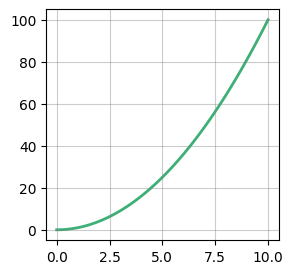

In [4]:
plt.figure(figsize = (3, 3))
plt.plot(x_train, y_train, linewidth = 2, zorder = 1, color = "xkcd:dark seafoam green")
plt.grid(alpha = 0.4, color = "grey", zorder = 0)
plt.show()

In [5]:
def my_func(x, y, a, b):
    x_new = max(0.098, x)
    y_new = max(0.10, y)
    if y_new / x_new > 1:
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
    else:
        x_new = 0.99 * y_new
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
        
    z_positive = max(z, 0)
    return round(z_positive, 3)

def new_func(lambda_i, y, a, b):
    return y * (1 + np.exp(a - b * lambda_i))**-1
    
def calculate_flexibility_cost(x, y, shaping_parameters):
    a, b = shaping_parameters
    return my_func(x, y, a, b)

In [6]:
x_val = np.linspace(-10, 60, 100)
y = 10
a = 6
b = 0.25

z_val = np.array([new_func(x, y, a, b) for x in x_val])

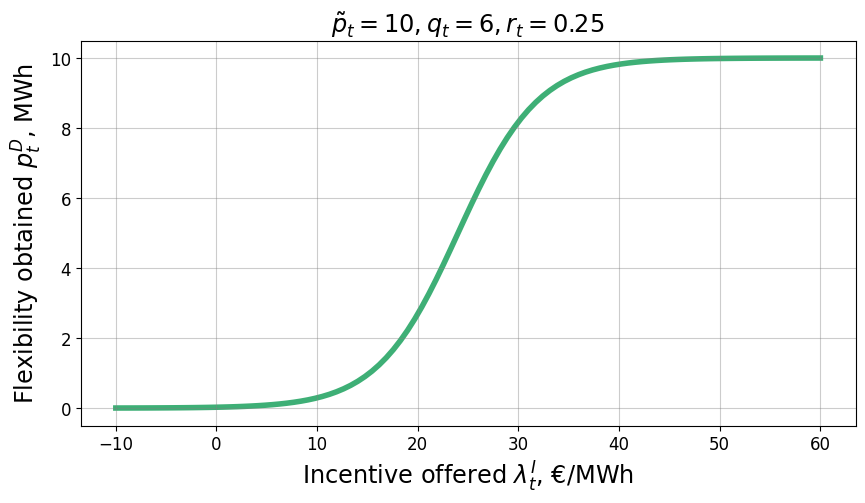

In [7]:
plt.figure(figsize = (10, 5))
plt.plot(x_val, z_val, linewidth = 4, zorder = 1, color = "xkcd:dark seafoam green")
plt.grid(alpha = 0.4, color = "grey", zorder = 0)
plt.xlabel("Incentive offered $\\lambda_t^{I}$, \u20ac/MWh", fontsize="xx-large")
plt.ylabel("Flexibility obtained $p_t^{D}$, MWh",  fontsize="xx-large")
plt.xticks(fontsize="large")
plt.yticks(fontsize="large")
plt.title("$\\tilde{p}_t=10, q_t=6, r_t=0.25$",  fontsize="xx-large")
# plt.savefig("saturation_curve.svg", bbox_inches="tight")
plt.show()

# Train the neural network

In [8]:
import tensorflow as tf
from keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.constraints import non_neg

In [30]:
tf.random.set_seed(42)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model = Sequential([
    Input(shape=(1, 1)),
    Dense(12, activation = 'relu'),
    # Dense(24, activation = 'relu'), 
    # Dense(48, activation = 'relu'),
    # Dense(24, activation = 'relu'),
    # Dense(12, activation = 'relu'),
    Dense(1, activation = 'linear') 
])

model.compile(optimizer = optimizer, loss = 'mae', metrics = ['mae'])

history = model.fit(x_train, y_train, epochs = 300, batch_size = 10)


Epoch 1/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 36.3746 - mae: 36.3746  
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 36.1596 - mae: 36.1596 
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 35.9510 - mae: 35.9510 
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35.7517 - mae: 35.7517 
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step - loss: 35.5742 - mae: 35.5742
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35.4222 - mae: 35.4222 
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35.2743 - mae: 35.2743 
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35.1294 - mae: 35.1294 
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 34.9865 - mae: 34.9865 
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 34.8453 - mae: 34.8453 
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34.7060 - mae: 34.7060 
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 34.5680 - mae: 34.5680 

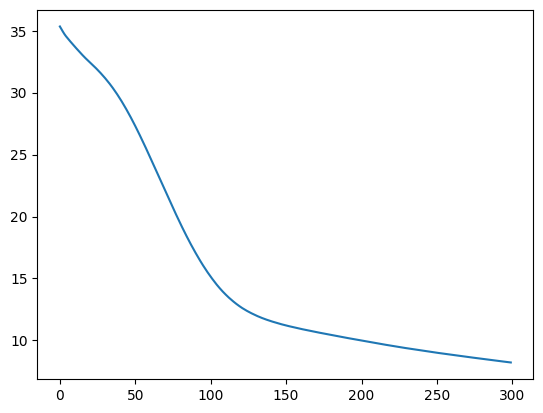

In [31]:
plt.plot(history.history['loss'])
plt.show()

In [32]:
model.save(os.path.join(cwd, "NN models", "x2_NN_1layer.keras"))